# Importar Bibliotecas

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Carregamento dos dados

In [80]:
df = pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# Exploração do Dataset

In [81]:
print("Número de linhas e colunas:")
print(df.shape)

print("\nInformações gerais:")
df.info()

print("\nValores ausentes:")
print(df.isnull().sum())

Número de linhas e colunas:
(21613, 21)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  in

# Seleção das Variáveis

In [82]:
X = df.drop(["id", "date", "price"], axis=1)
y = df["price"]

nomes_features = X.columns

print(X.shape)
print(y.shape)

(21613, 18)
(21613,)


# Função de Avaliação do Modelo

In [83]:
def avaliar_modelo(X, y, test_size, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"Test Size = {test_size*100:.0f}%")
    print(f"R² (Explicação da variância): {r2:.4f}")
    print(f"MAE (Erro Médio em $):        {mae:,.2f}")
    print(f"RMSE (Penaliza grandes erros): {rmse:,.2f}\n")

    return y_test, y_pred, r2

# Execução

In [84]:
y_test_70, y_pred_70, r2_70 = avaliar_modelo(X, y, test_size=0.30)

y_test_90, y_pred_90, r2_90 = avaliar_modelo(X, y, test_size=0.10)

Test Size = 30%
R² (Explicação da variância): 0.6995
MAE (Erro Médio em $):        127,486.80
RMSE (Penaliza grandes erros): 208,296.73

Test Size = 10%
R² (Explicação da variância): 0.6902
MAE (Erro Médio em $):        129,572.13
RMSE (Penaliza grandes erros): 212,443.13



# Visualização

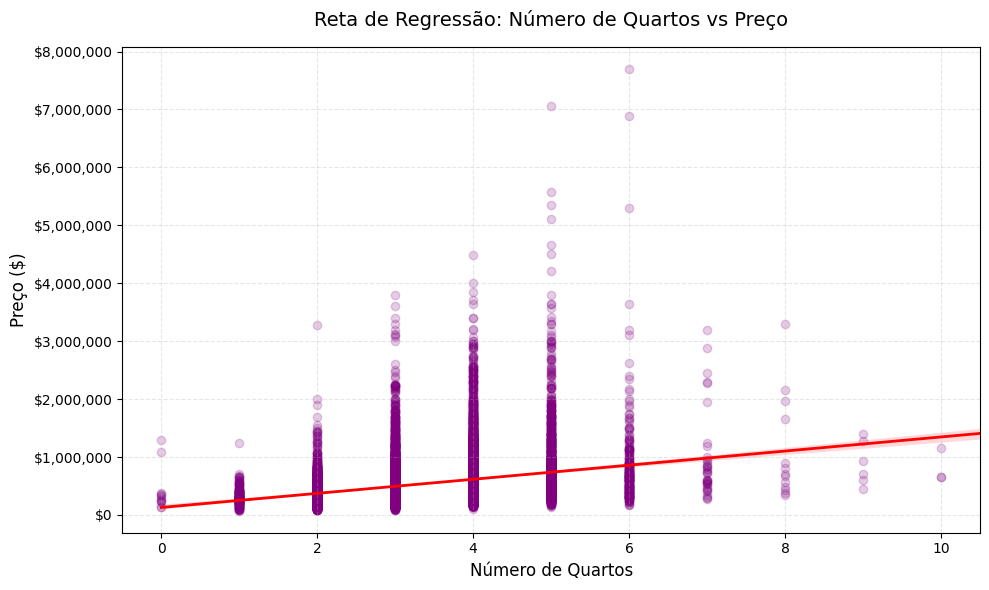

In [78]:
# Numero de Quartos x Preço

plt.figure(figsize=(10, 6))
ax = sns.regplot(data=df, x='bedrooms', y='price', scatter_kws={'alpha': 0.2, 'color': 'purple'}, line_kws={'color': 'red', 'linewidth': 2})

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}"))

plt.xlim(-0.5, 10.5)
plt.title('Reta de Regressão: Número de Quartos vs Preço', fontsize=14, pad=15)
plt.xlabel('Número de Quartos', fontsize=12)
plt.ylabel('Preço ($)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

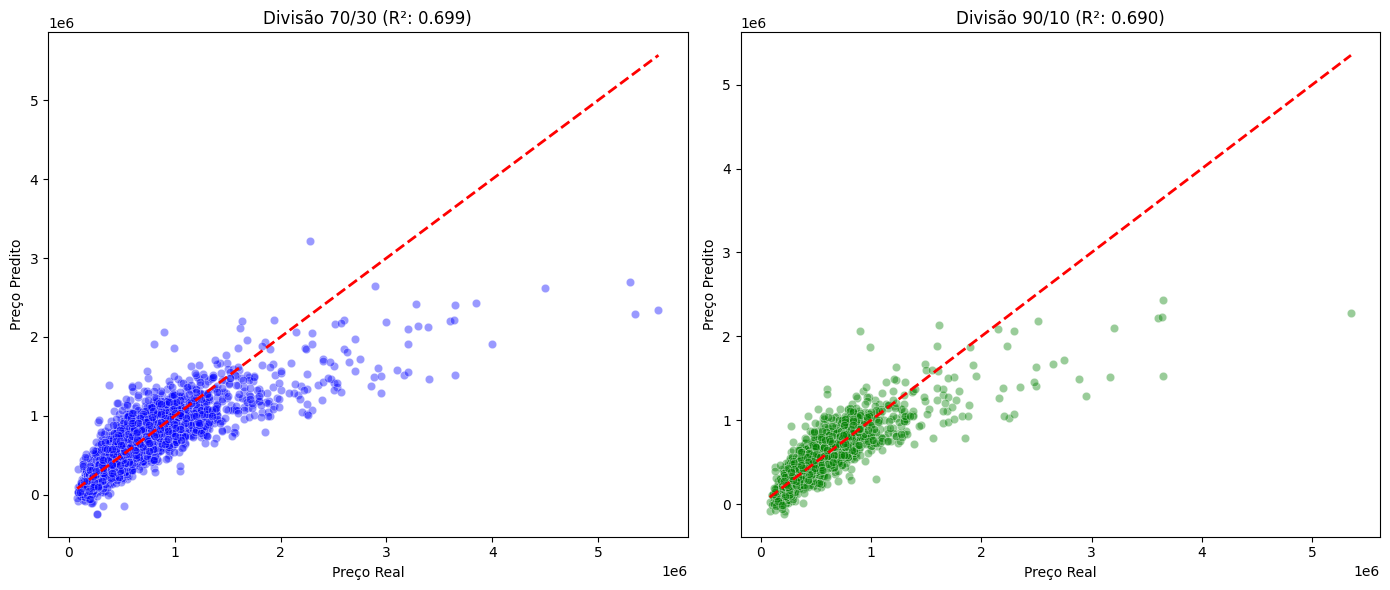

In [85]:
plt.figure(figsize=(14, 6))

# Gráfico para a divisão 70/30
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_70, y=y_pred_70, alpha=0.4, color='blue')
plt.plot([y_test_70.min(), y_test_70.max()], [y_test_70.min(), y_test_70.max()], 'r--', lw=2)
plt.title(f'Divisão 70/30 (R²: {r2_70:.3f})')
plt.xlabel('Preço Real')
plt.ylabel('Preço Predito')

# Gráfico para a divisão 90/10
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_90, y=y_pred_90, alpha=0.4, color='green')
plt.plot([y_test_90.min(), y_test_90.max()], [y_test_90.min(), y_test_90.max()], 'r--', lw=2)
plt.title(f'Divisão 90/10 (R²: {r2_90:.3f})')
plt.xlabel('Preço Real')
plt.ylabel('Preço Predito')

plt.tight_layout()
plt.show()

# Respostas



### 1. Qual foi o valor do R² obtido?
* **Divisão 70/30:** $R^2 = 0.6995$.
* **Divisão 90/10:** $R^2 = 0.6902$.


### 2. O que esse valor significa?
O $R^2$ (Coeficiente de Determinação) indica a porcentagem da variação dos preços das casas que o modelo consegue explicar através das variáveis preditoras. Um valor de aproximadamente 0.70 significa que 70% da variação dos preços dos imóveis é explicada pelo modelo, enquanto os 30% restantes se devem a fatores não mapeados ou ruídos nos dados.


### 3. O que aconteceu quando você mudou a proporção de treino/teste?
Ao mudar de 70/30 para 90/10, o $R^2$ sofreu uma leve redução (de 0.6995 para 0.6902) e o erro médio (MAE) aumentou de \$127,486.80 para \$129,572.13.

Isso ocorre porque, com apenas 10% dos dados para teste, a base avaliada fica menor e se torna mais sensível a outliers (valores discrepantes, como a casa com 33 quartos presente no dataset), o que penaliza as métricas finais do modelo.